In [106]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

In [108]:
data = pd.read_csv("data/Book 4(Sheet1)(in).csv")
data.head()


,Trial,config number,mass 1 (g),d(mass 1) (g),mass 2 (g),d (mass 2) (g),v_i (m/s),d(vi) (m/s),v_f(m/s),d(v_f) (m/s),F_pred,d(F_pred),v_f/v_i,d(v_f/v_i)
0,1,1,379.6,0.1,179.6,0.1,0.449,0.2,0.311,0.2,NaN,NaN,NaN,NaN
1,2,2,179.6,0.1,379.6,0.1,0.801,0.2,0.239,0.2,NaN,NaN,NaN,NaN


We can measure the Kinetic Energy lost by the formula:
$$
F = 1 - \left( \frac{m_1 + m_2}{m_1} \right)(\frac{v_f}{v_2})^2
$$


The uncertainity associated with F is: 
$$
\sigma_F = \sqrt{ \left( \frac{(m_2 - m_1) v^2}{m_1^2} \sigma_{m_1} \right)^2 + \left( -\frac{v^2}{m_1} \sigma_{m_2} \right)^2 + \left( -2 \left( \frac{m_1 + m_2}{m_1} \right) v \sigma_v \right)^2 }
$$


But since the uncertainity of mass1 and mass2 is small compared to the mass of the carts we can consider them as negligable

$$
\sigma_F = \sqrt {(-2 \left( \frac{m_1 + m_2}{m_1} \right) v \sigma_v)^2}
$$


In [113]:
# defining the functions to calculate the kinetic energy lost and its associated error

F_measured = lambda mass_1, mass_2, v: [1 - (((mass_1[i] + mass_2[i]) / mass_1[i]) * (v[i])**2) for i in range(len(mass_1))]
F_pred = lambda mass_1, mass_2: [mass_2[i] / (mass_2[i] + mass_1[i]) for i in range(len(mass_1))]
F_error = lambda mass_1, mass_2, v, v_err: [np.sqrt((-2 * ((mass_1[i] + mass_2[i]) / mass_1[i]) * ((v[i]) * v_err))**2) for i in range(len(mass_1))]

In [115]:
# populating v_f / V_i , F_pred, and F_measured with their assosiated uncertainity

data['v_f/v_i'] = data['v_f(m/s)'] / data['v_i (m/s)']
data['F_pred'] = F_pred(data['mass 1 (g)'], data['mass 2 (g)'])
data['F_measured'] = F_measured(data["mass 1 (g)"], data["mass 2 (g)"], data['v_f/v_i'])
data['d(v_f/v_i)'] = data['F_measured'].std()
data['d(F_pred)'] = F_error(data["mass 1 (g)"], data["mass 2 (g)"], data['v_f/v_i'], data['d(v_f/v_i)'][0])

# Now that we have populated the data we are going to round the numbers to the desired sig figs

In [118]:
# Rounds numbers to the desired sig fig


data["F_pred"] = data["F_pred"].apply(lambda x: round(x, 2))
data["d(F_pred)"] = data["d(F_pred)"].apply(lambda x: round(x, 2))
data["v_f/v_i"] = data["v_f/v_i"].apply(lambda x: round(x, 2))
data["d(v_f/v_i)"] = data["d(v_f/v_i)"].apply(lambda x: round(x, 2))
data["F_measured"] = data["F_measured"].apply(lambda x: round(x, 2))

In [120]:
data.head()

,Trial,config number,mass 1 (g),d(mass 1) (g),mass 2 (g),d (mass 2) (g),v_i (m/s),d(vi) (m/s),v_f(m/s),d(v_f) (m/s),F_pred,d(F_pred),v_f/v_i,d(v_f/v_i),F_measured
0,1,1,379.6,0.1,179.6,0.1,0.449,0.2,0.311,0.2,0.32,0.62,0.69,0.3,0.29
1,2,2,179.6,0.1,379.6,0.1,0.801,0.2,0.239,0.2,0.68,0.56,0.30,0.3,0.72


### To check if our F_measured is close to F_predicted we would plot a line between our two measured points

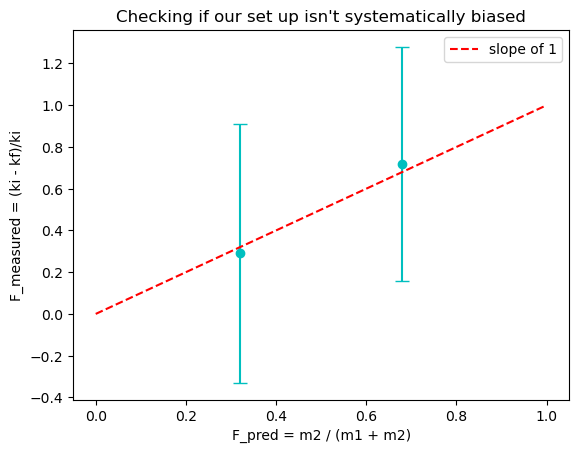

In [123]:
fig, ax = plt.subplots()
ax.errorbar(data['F_pred'], data['F_measured'], c='c', fmt='o', yerr=data["d(F_pred)"], capsize = 5)
x = np.linspace(0, 1, 1000)   
ax.plot(x, 1 * x, linestyle='--', c='r', label = 'slope of 1')
ax.set_title("Checking if our set up isn't systematically biased")
ax.set_xlabel("F_pred = m2 / (m1 + m2)")
ax.set_ylabel("F_measured = (ki - kf)/ki")
ax.legend()
pass

##### The accepted value for the slope is 1 and since our two data points have a slope close to 1 we can proceed collecting more data points

# Getting statistics on Vf/vi, F_pred, F_measured and their associated errors

In [127]:
data = pd.read_csv("data/lab4data2(in).csv")

In [129]:
data.head()

,Trial,config number,mass 1 (g),d(mass 1) (g),mass 2 (g),d (mass 2) (g),v_i (m/s),d(vi) (m/s),v_f(m/s),d(v_f) (m/s),F_pred,d(F_pred),v_f/v_i,d(v_f/v_i)
0,1,1,379.6,0.1,179.6,0.1,0.449,0.2,0.311,0.2,NaN,NaN,NaN,NaN
1,2,2,179.6,0.1,379.6,0.1,0.801,0.2,0.239,0.2,NaN,NaN,NaN,NaN
2,3,3,279.6,0.1,279.6,0.1,0.666,0.2,0.310,0.2,NaN,NaN,NaN,NaN
3,4,3,279.6,0.1,279.6,0.1,1.346,0.2,0.520,0.2,NaN,NaN,NaN,NaN
4,5,3,279.6,0.1,279.6,0.1,1.000,0.2,0.406,0.2,NaN,NaN,NaN,NaN


In [131]:
# populating v_f / V_i , F_pred, and F_measured 

data['v_f/v_i'] = data['v_f(m/s)'] / data['v_i (m/s)']
data['F_pred'] = F_pred(data['mass 1 (g)'], data['mass 2 (g)'])
data['F_measured'] = F_measured(data["mass 1 (g)"], data["mass 2 (g)"], data['v_f/v_i'])

# populating the uncertainities
data['d(v_f/v_i)'] = data['F_measured'].std()
data['d(F_pred)'] = F_error(data["mass 1 (g)"], data["mass 2 (g)"], data['v_f/v_i'], data['d(v_f/v_i)'][0])

In [133]:
data["F_pred"] = data["F_pred"].apply(lambda x: round(x, 2))
data["d(F_pred)"] = data["d(F_pred)"].apply(lambda x: round(x, 2))
data["v_f/v_i"] = data["v_f/v_i"].apply(lambda x: round(x, 2))
data["d(v_f/v_i)"] = data["d(v_f/v_i)"].apply(lambda x: round(x, 2))
data["F_measured"] = data["F_measured"].apply(lambda x: round(x, 2))
data.head()

,Trial,config number,mass 1 (g),d(mass 1) (g),mass 2 (g),d (mass 2) (g),v_i (m/s),d(vi) (m/s),v_f(m/s),d(v_f) (m/s),F_pred,d(F_pred),v_f/v_i,d(v_f/v_i),F_measured
0,1,1,379.6,0.1,179.6,0.1,0.449,0.2,0.311,0.2,0.32,0.28,0.69,0.13,0.29
1,2,2,179.6,0.1,379.6,0.1,0.801,0.2,0.239,0.2,0.68,0.25,0.30,0.13,0.72
2,3,3,279.6,0.1,279.6,0.1,0.666,0.2,0.310,0.2,0.50,0.25,0.47,0.13,0.57
3,4,3,279.6,0.1,279.6,0.1,1.346,0.2,0.520,0.2,0.50,0.21,0.39,0.13,0.70
4,5,3,279.6,0.1,279.6,0.1,1.000,0.2,0.406,0.2,0.50,0.22,0.41,0.13,0.67



 ## Calculating the mean and standard deviation and plotting an error bar for our scatter

In [136]:
bins = {}

## What this code does is it groups the data based on 
## their configration number the first two rows are
## ignored in our dataset as they were used to check 
## the relationship between f_pred and f_measured

for i in range(len(data)):
    if (data["config number"][i] not in bins and data["config number"][i] > 2):
        bins[data["config number"][i]] = [i]
    elif (data["config number"][i] in bins):
        bins[data["config number"][i]].append(i)
    else:
        # check if there are any corrupted data measurments
        assert data["config number"][i] <= 2, "something went wrong"

        

In [138]:
# group our data by their cofigration
# number

for key, value in bins.items():
    print(f"{key}: {value}")

3: [2, 3, 4, 5, 6]
4: [7, 8, 9, 10, 11]
5: [12, 13, 14, 15, 16]
6: [17, 18, 19, 20, 21]
7: [22, 23, 24, 25, 26]
8: [27, 28, 29, 30, 31]


In [140]:
means = []
# calculating the standard deviation
# for each configration number
std = [np.std([data["F_measured"][index] for index in bins.values()], ddof=1) for i in range(len(bins))]

# calculating the mean for
# each configration number
for key in bins.keys():
    sum = 0
    for index in bins[key]:
        sum += data["F_measured"][index]
    means.append(sum / 5)

means = [round_sig(means[i], 3) for i in range(len(means))]
std = [round_sig(std[i], 3) for i in range(len(std))]


# Ploting The Error Bar to get a Sense of the F_measured

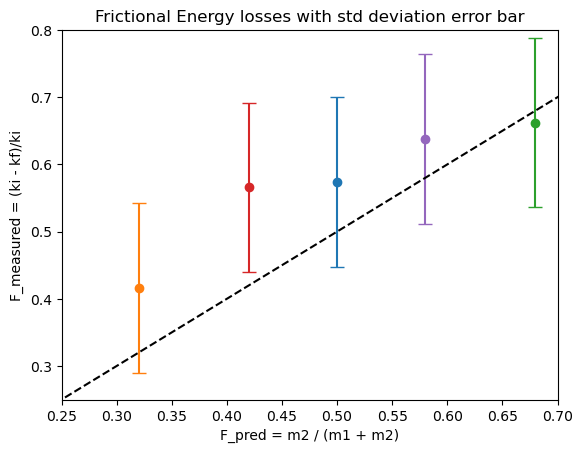

In [143]:
# The index of the first elements in each bins to get the x val for
# F predicted
index = [2, 7, 12, 17, 22] 

fig, ax = plt.subplots()
for i in range(len(index)):
    # plotting the error bar for each configration number
    ax.errorbar(data["F_pred"][index[i]], means[i], yerr=std[i], fmt='o', capsize=5)

ax.set_xlabel("F_pred = m2 / (m1 + m2)")
ax.set_ylabel("F_measured = (ki - kf)/ki")
ax.set_title("Frictional Energy losses with std deviation error bar")
x = np.linspace(0, 1, 1000)
ax.plot(x, 1 * x, c = 'black', linestyle='--')
ax.set_xlim(0.25, 0.7) 
ax.set_ylim(0.25, 0.8)
pass

# The dominant source of this uncertainity is the inclind of our table which led to gravity accelerating or decelerating the carts

#### Lets find the average slope of our F_pred and F_measured

In [157]:
X = [data["F_pred"][i] for i in range(5)]
Y = [means[i] for i in range(5)]
uncertainity = [std[i] for i in range(5)]

In [159]:
linear_model = lambda x, A, B: (x * A) + B
parameters, cov = curve_fit(linear_model, X, Y, sigma = uncertainity)
# rounding to the appropriate sig fig
for i in range(len(parameters)):
    parameters[i] = round_sig(parameters[i])
    
print(f"Slope = {parameters[1]}, Intercept = {parameters[0]}")

Slope = 0.79, Intercept = -0.44


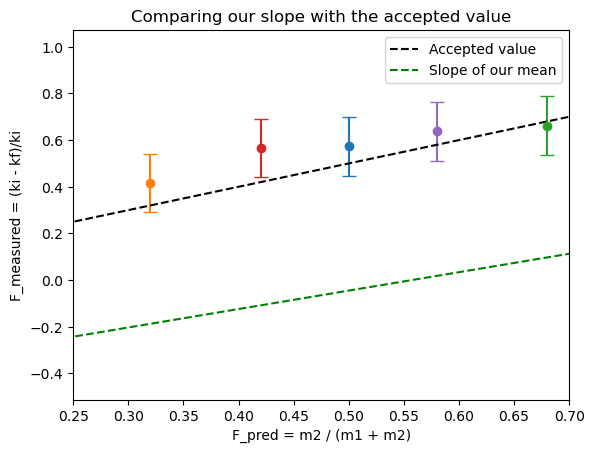

In [161]:
index = [2, 7, 12, 17, 22] 

fig, ax = plt.subplots()
for i in range(len(index)):
    # plotting the error bar for each configration number
    ax.errorbar(data["F_pred"][index[i]], means[i], yerr=std[i], fmt='o', capsize=5)

ax.set_xlabel("F_pred = m2 / (m1 + m2)")
ax.set_ylabel("F_measured = (ki - kf)/ki")
ax.set_title("Comparing our slope with the accepted value")
x = np.linspace(0, 1, 1000)
ax.plot(x, 1 * x, c = 'black', linestyle='--', label = 'Accepted value')
ax.plot(x, parameters[1] * x + parameters[0], linestyle='--', label = 'Slope of our mean', c = 'g')
ax.set_xlim(0.25, 0.7) 

ax.legend()
pass

$$
\text{slope} = 0.79 \pm 0.13 \\
\text{intercept} = -0.44 \pm 0.13
$$

# Comparison to the accepted value

##### Since our Frictional Energy lost due to friction must be close to the predicted energy loss our measurments fall short of the accepted value of slope 1 and intercept of 0. Our initial measurments had a systematic bias where our F_measured was almost always  greater than the F predicted by a certain amount

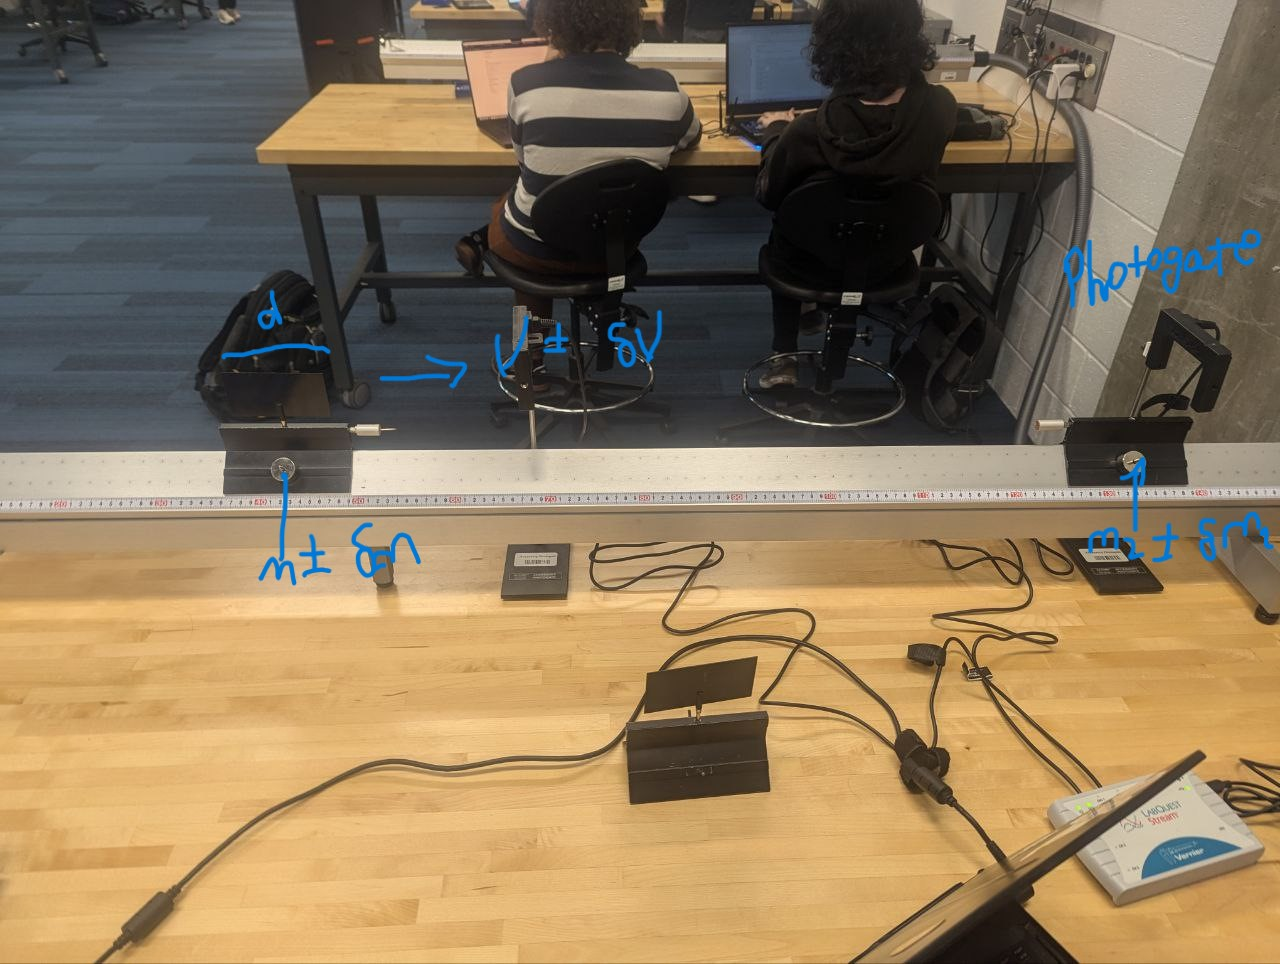